In [1]:
import numpy as np
import matplotlib.pyplot as plt
# roll number seed
s = 5390
print("roll seed:", s)


roll seed: 5390


In [2]:
# generate synthetic classification dataset using specified seeds
rng_data = np.random.default_rng(10000 + s)
n = 600
x1 = rng_data.normal(0.0, 1.0, n)
x2 = rng_data.normal(0.0, 25.0, n)
x3 = rng_data.normal(0.0, 0.30, n)
x_mat = np.column_stack([x1, x2, x3])
z_true = -0.65 + 1.40 * x1 - 0.055 * x2 + 2.20 * x3
p_true = 1.0 / (1.0 + np.exp(-z_true))
y = rng_data.binomial(1, p_true)
# split data into fit validation and holdout sets
rng_split = np.random.default_rng(20000 + s)
perm = rng_split.permutation(n)
n_fit = int(0.70 * n)
n_val = int(0.15 * n)
n_hld = n - n_fit - n_val
idx_fit = perm[:n_fit]
idx_val = perm[n_fit:n_fit+n_val]
idx_hld = perm[n_fit+n_val:]
print(f"split sizes: fit = {n_fit}, validation = {n_val}, holdout = {n_hld}")
print("first five fit indices:", idx_fit[:5].tolist())
print("first five validation indices:", idx_val[:5].tolist())
print("first five holdout indices:", idx_hld[:5].tolist())
x_raw_fit = x_mat[idx_fit]
y_fit = y[idx_fit]
x_raw_val = x_mat[idx_val]
y_val = y[idx_val]
x_raw_hld = x_mat[idx_hld]
y_hld = y[idx_hld]
# standardize features using fit set statistics only
mu = np.mean(x_raw_fit, axis=0)
sigma = np.std(x_raw_fit, axis=0)
x_std_fit = (x_raw_fit - mu) / sigma
x_std_val = (x_raw_val - mu) / sigma
x_std_hld = (x_raw_hld - mu) / sigma
# prepend bias column of ones
x_fit_b = np.column_stack([np.ones(n_fit), x_std_fit])
x_val_b = np.column_stack([np.ones(n_val), x_std_val])
x_hld_b = np.column_stack([np.ones(n_hld), x_std_hld])

split sizes: fit = 420, validation = 90, holdout = 90
first five fit indices: [542, 559, 317, 42, 180]
first five validation indices: [449, 280, 183, 222, 119]
first five holdout indices: [32, 422, 246, 597, 557]


In [3]:
# define stable sigmoid function
def sigmoid(z):
    return np.where(z >= 0, 1.0 / (1.0 + np.exp(-z)), np.exp(z) / (1.0 + np.exp(z)))
# compute stable binary cross entropy using log add exp
# working directly with log add exp avoids overflow and underflow
def bce_loss(th, x, y_true):
    z = x @ th
    return np.mean(np.logaddexp(0.0, z) - y_true * z)
# compute analytical gradient of binary cross entropy
#If we calculate probabilities p first and then take logp, wehn p=0 or extreama valus of z  
# resulting in log(0)=−infinity . Using logaddexp(0,z)=log(1+ez) we can avoid this  underflow and overflow
def bce_grad(th, x, y_true):
    z = x @ th
    p = sigmoid(z)
    return (1.0 / len(y_true)) * (x.T @ (p - y_true))
# evaluate loss at initial zero vector
th_zero = np.zeros(x_fit_b.shape[1])
init_loss = bce_loss(th_zero, x_fit_b, y_fit)
print(f"initial loss at zero weights: {init_loss:.5f}")

initial loss at zero weights: 0.69315


In [4]:
# draw check point from normal distribution
rng_chk = np.random.default_rng(30000 + s)
theta_check = rng_chk.normal(loc=0.0, scale=0.1, size=x_fit_b.shape[1])
eps = 1e-5
# compute analytical gradient at check point
g_anal = bce_grad(theta_check, x_fit_b, y_fit)
# compute numerical gradient using central finite difference
g_num = np.zeros_like(theta_check)
for j in range(len(theta_check)):
    # perturb each coordinate by small epsilon
    e_j = np.zeros_like(theta_check)
    e_j[j] = 1.0
    l_plus = bce_loss(theta_check + eps * e_j, x_fit_b, y_fit)
    l_minus = bce_loss(theta_check - eps * e_j, x_fit_b, y_fit)
    g_num[j] = (l_plus - l_minus) / (2.0 * eps)
# evaluate maximum absolute difference
max_abs_err = np.max(np.abs(g_anal - g_num))
status = "PASS" if max_abs_err < 1e-5 else "FAIL"
print("finite difference gradient checker results:")
print("evaluation point theta_check:", np.round(theta_check, 5))
print("analytical gradient:         ", np.round(g_anal, 7))
print("numerical gradient:          ", np.round(g_num, 7))
print(f"maximum absolute error:       {max_abs_err:.4e}")
print(f"gradient checker status:      {status}")


finite difference gradient checker results:
evaluation point theta_check: [-0.01138 -0.05959  0.21545  0.19693]
analytical gradient:          [ 0.061486  -0.2072442  0.2432978 -0.0223923]
numerical gradient:           [ 0.061486  -0.2072442  0.2432978 -0.0223923]
maximum absolute error:       4.9342e-12
gradient checker status:      PASS


learning rate = 0.01: final fit bce = 0.49221, final val bce = 0.36096
learning rate = 0.1: final fit bce = 0.49218, final val bce = 0.35951
learning rate = 1.0: final fit bce = 0.49218, final val bce = 0.35951

selected learning rate based on validation bce: 1.0


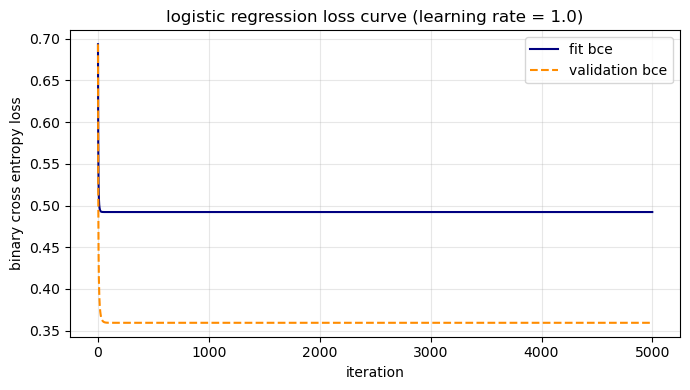

In [5]:
# define candidate learning rates
lr_candidates = [0.01, 0.1, 1.0]
t_iters = 5000
lr_results = {}
# train unregularized logistic regression for fixed iterations
for lr in lr_candidates:
    th = np.zeros(x_fit_b.shape[1])
    fit_curve = []
    val_curve = []
    for t in range(t_iters):
        loss_f = bce_loss(th, x_fit_b, y_fit)
        loss_v = bce_loss(th, x_val_b, y_val)
        fit_curve.append(loss_f)
        val_curve.append(loss_v)
        # update weights using batch gradient descent
        g = bce_grad(th, x_fit_b, y_fit)
        th = th - lr * g
    final_f = bce_loss(th, x_fit_b, y_fit)
    final_v = bce_loss(th, x_val_b, y_val)
    lr_results[lr] = {
        'th': th,
        'fit_bce': final_f,
        'val_bce': final_v,
        'fit_curve': fit_curve,
        'val_curve': val_curve
    }
    print(f"learning rate = {lr}: final fit bce = {final_f:.5f}, final val bce = {final_v:.5f}")
# select best learning rate using validation error
best_lr = min(lr_candidates, key=lambda lr: lr_results[lr]['val_bce'])
print(f"\nselected learning rate based on validation bce: {best_lr}")
# plot training and validation loss curves for selected rate
plt.figure(figsize=(7, 4))
plt.plot(lr_results[best_lr]['fit_curve'], label='fit bce', color='navy')
plt.plot(lr_results[best_lr]['val_curve'], label='validation bce', color='darkorange', linestyle='--')
plt.xlabel('iteration')
plt.ylabel('binary cross entropy loss')
plt.title(f'logistic regression loss curve (learning rate = {best_lr})')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('b2_loss_curve.png', dpi=150)
plt.show()

In [6]:
# create regularization matrix leaving bias unpenalized
p_reg = np.eye(x_fit_b.shape[1])
p_reg[0, 0] = 0.0
# define candidate regularizer penalty values
l2_lams = [0.0, 1e-3, 1e-2, 1e-1]
l2_results = {}
# train regularized logistic regression models
for lam in l2_lams:
    th = np.zeros(x_fit_b.shape[1])
    for t in range(t_iters):
        z = x_fit_b @ th
        p = sigmoid(z)
        # add penalty term to gradient update
        g = (1.0 / n_fit) * (x_fit_b.T @ (p - y_fit)) + lam * (p_reg @ th)
        th = th - best_lr * g
    val_bce = bce_loss(th, x_val_b, y_val)
    w_norm = np.linalg.norm(th[1:])
    l2_results[lam] = {
        'th': th,
        'val_bce': val_bce,
        'w_norm': w_norm
    }
    print(f"lambda = {lam:6.1e}: val bce = {val_bce:.5f}, weight norm ||w||_2 = {w_norm:.5f}, parameters = {np.round(th, 4)}")
# evaluate validation loss and weight norm for each penalty
best_l2_lam = min(l2_lams, key=lambda lam: l2_results[lam]['val_bce'])
chosen_th = l2_results[best_l2_lam]['th']
print(f"\nselected lambda: {best_l2_lam}")
print("chosen model parameters:", np.round(chosen_th, 5))

lambda = 0.0e+00: val bce = 0.35951, weight norm ||w||_2 = 1.73106, parameters = [-0.3958  1.1146 -1.2006  0.5594]
lambda = 1.0e-03: val bce = 0.36063, weight norm ||w||_2 = 1.70832, parameters = [-0.3932  1.101  -1.1843  0.551 ]
lambda = 1.0e-02: val bce = 0.37021, weight norm ||w||_2 = 1.54067, parameters = [-0.3737  1.0001 -1.0646  0.49  ]
lambda = 1.0e-01: val bce = 0.43659, weight norm ||w||_2 = 0.90364, parameters = [-0.3064  0.6042 -0.6147  0.2714]

selected lambda: 0.0
chosen model parameters: [-0.39583  1.11456 -1.20059  0.55938]


In [7]:
# evaluate chosen regularized model on holdout set
hld_bce = bce_loss(chosen_th, x_hld_b, y_hld)
hld_probs = sigmoid(x_hld_b @ chosen_th)
hld_preds_50 = (hld_probs >= 0.5).astype(int)
hld_acc = np.mean(hld_preds_50 == y_hld)
# compute confusion matrix components from scratch
tn = np.sum((hld_preds_50 == 0) & (y_hld == 0))
fp = np.sum((hld_preds_50 == 1) & (y_hld == 0))
fn = np.sum((hld_preds_50 == 0) & (y_hld == 1))
tp = np.sum((hld_preds_50 == 1) & (y_hld == 1))
cm = np.array([[tn, fp], [fn, tp]])
print("holdout evaluation (threshold = 0.5):")
print(f"holdout bce:      {hld_bce:.5f}")
print(f"holdout accuracy: {hld_acc:.5f} ({hld_acc*100:.2f}%)")
print("\nconfusion matrix [ [ tn , fp ] , [ fn , tp ] ]:")
print(cm)
# evaluate performance across different decision thresholds
thresholds = [0.30, 0.50, 0.70]
print("\ndecision threshold comparison:")
for t_val in thresholds:
    p_pred = (hld_probs >= t_val).astype(int)
    fp_t = np.sum((p_pred == 1) & (y_hld == 0))
    fn_t = np.sum((p_pred == 0) & (y_hld == 1))
    acc_t = np.mean(p_pred == y_hld)
    print(f"threshold = {t_val:.2f}: false positives = {fp_t}, false negatives = {fn_t}, accuracy = {acc_t:.5f}")

holdout evaluation (threshold = 0.5):
holdout bce:      0.38512
holdout accuracy: 0.81111 (81.11%)

confusion matrix [ [ tn , fp ] , [ fn , tp ] ]:
[[48  8]
 [ 9 25]]

decision threshold comparison:
threshold = 0.30: false positives = 18, false negatives = 2, accuracy = 0.77778
threshold = 0.50: false positives = 8, false negatives = 9, accuracy = 0.81111
threshold = 0.70: false positives = 2, false negatives = 19, accuracy = 0.76667


In [8]:
# compute individual cross entropy contributions on holdout set
z_hld = x_hld_b @ chosen_th
indiv_bce = np.logaddexp(0.0, z_hld) - y_hld * z_hld
max_idx = np.argmax(indiv_bce)
worst_x_std = x_std_hld[max_idx]
worst_y = y_hld[max_idx]
worst_p = hld_probs[max_idx]
worst_pred_50 = hld_preds_50[max_idx]
worst_bce = indiv_bce[max_idx]
# identify holdout sample with highest loss penalty
print("worst holdout sample analysis:")
print(f"sample index in holdout:         {max_idx}")
print(f"standardized feature vector:     {np.round(worst_x_std, 5)}")
print(f"true class label:                {worst_y}")
print(f"predicted probability:           {worst_p:.5f}")
print(f"predicted class (threshold 0.5): {worst_pred_50}")
print(f"individual bce loss penalty:     {worst_bce:.5f}")

worst holdout sample analysis:
sample index in holdout:         52
standardized feature vector:     [ 0.82971 -0.42506  0.27683]
true class label:                0
predicted probability:           0.76748
predicted class (threshold 0.5): 1
individual bce loss penalty:     1.45876
